# Patient EDA: Diabetes Health Indicators

**Exploratory Data Analysis** — distributions, correlations & class imbalance

- **Dataset:** [Kaggle — Diabetes Health Indicators](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)
- **Target:** `Diabetes_binary` (0 = no diabetes, 1 = diabetes/prediabetes)
- **Size:** ~253,000 rows, 22 features

---

## Section 1 — Imports & config

In [ ]:
# Install any missing packages (Colab already has most)
# !pip install seaborn --upgrade

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {0: '#378ADD', 1: '#D85A30'}  # blue = no diabetes, coral = diabetes
TARGET = 'Diabetes_binary'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Section 2 — Load dataset

**Option A — Upload manually in Colab:**  
Run the upload cell below, then select your CSV.

**Option B — Load directly from Kaggle API:**  
Uncomment the Kaggle block (requires `kaggle.json` credentials).

In [ ]:
# --- Option A: Manual upload ---
from google.colab import files
uploaded = files.upload()  # select your CSV when prompted
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Loaded via upload: {filename}')

Saving diabetes_binary_5050split_health_indicators_BRFSS2015.csv to diabetes_binary_5050split_health_indicators_BRFSS2015.csv
Loaded via upload: diabetes_binary_5050split_health_indicators_BRFSS2015.csv


In [ ]:
# --- Option B: Kaggle API (uncomment if you have kaggle.json) ---
# from google.colab import files
# files.upload()  # upload your kaggle.json here
# !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d alexteboul/diabetes-health-indicators-dataset --unzip
# df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
# print('Loaded via Kaggle API.')

## Section 3 — Data audit

In [ ]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nNull counts:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or '  No nulls found.')
print(f'\nData types:')
print(df.dtypes.to_string())

df.describe().T.style.background_gradient(cmap='Blues', axis=1)

Shape: 70,692 rows x 22 columns

Null counts:
Series([], )

Data types:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.000000,0.500000,0.500004,0.000000,0.000000,0.500000,1.000000,1.000000
HighBP,70692.000000,0.563458,0.495960,0.000000,0.000000,1.000000,1.000000,1.000000
HighChol,70692.000000,0.525703,0.499342,0.000000,0.000000,1.000000,1.000000,1.000000
CholCheck,70692.000000,0.975259,0.155336,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,70692.000000,29.856985,7.113954,12.000000,25.000000,29.000000,33.000000,98.000000
Smoker,70692.000000,0.475273,0.499392,0.000000,0.000000,0.000000,1.000000,1.000000
Stroke,70692.000000,0.062171,0.241468,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,70692.000000,0.147810,0.354914,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,70692.000000,0.703036,0.456924,0.000000,0.000000,1.000000,1.000000,1.000000
Fruits,70692.000000,0.611795,0.487345,0.000000,0.000000,1.000000,1.000000,1.000000


## Section 4 — Step 1: Feature distributions

Plotting distributions for BMI (continuous), Age (ordinal), HighBP and PhysActivity (binary).

- **BMI:** expect right skew — values above 40 are clinically significant outliers
- **Age:** ordinal scale 1–13 (1=18–24, 13=80+) — treat as categorical
- **HighBP / PhysActivity:** binary 0/1 — bar charts, not histograms

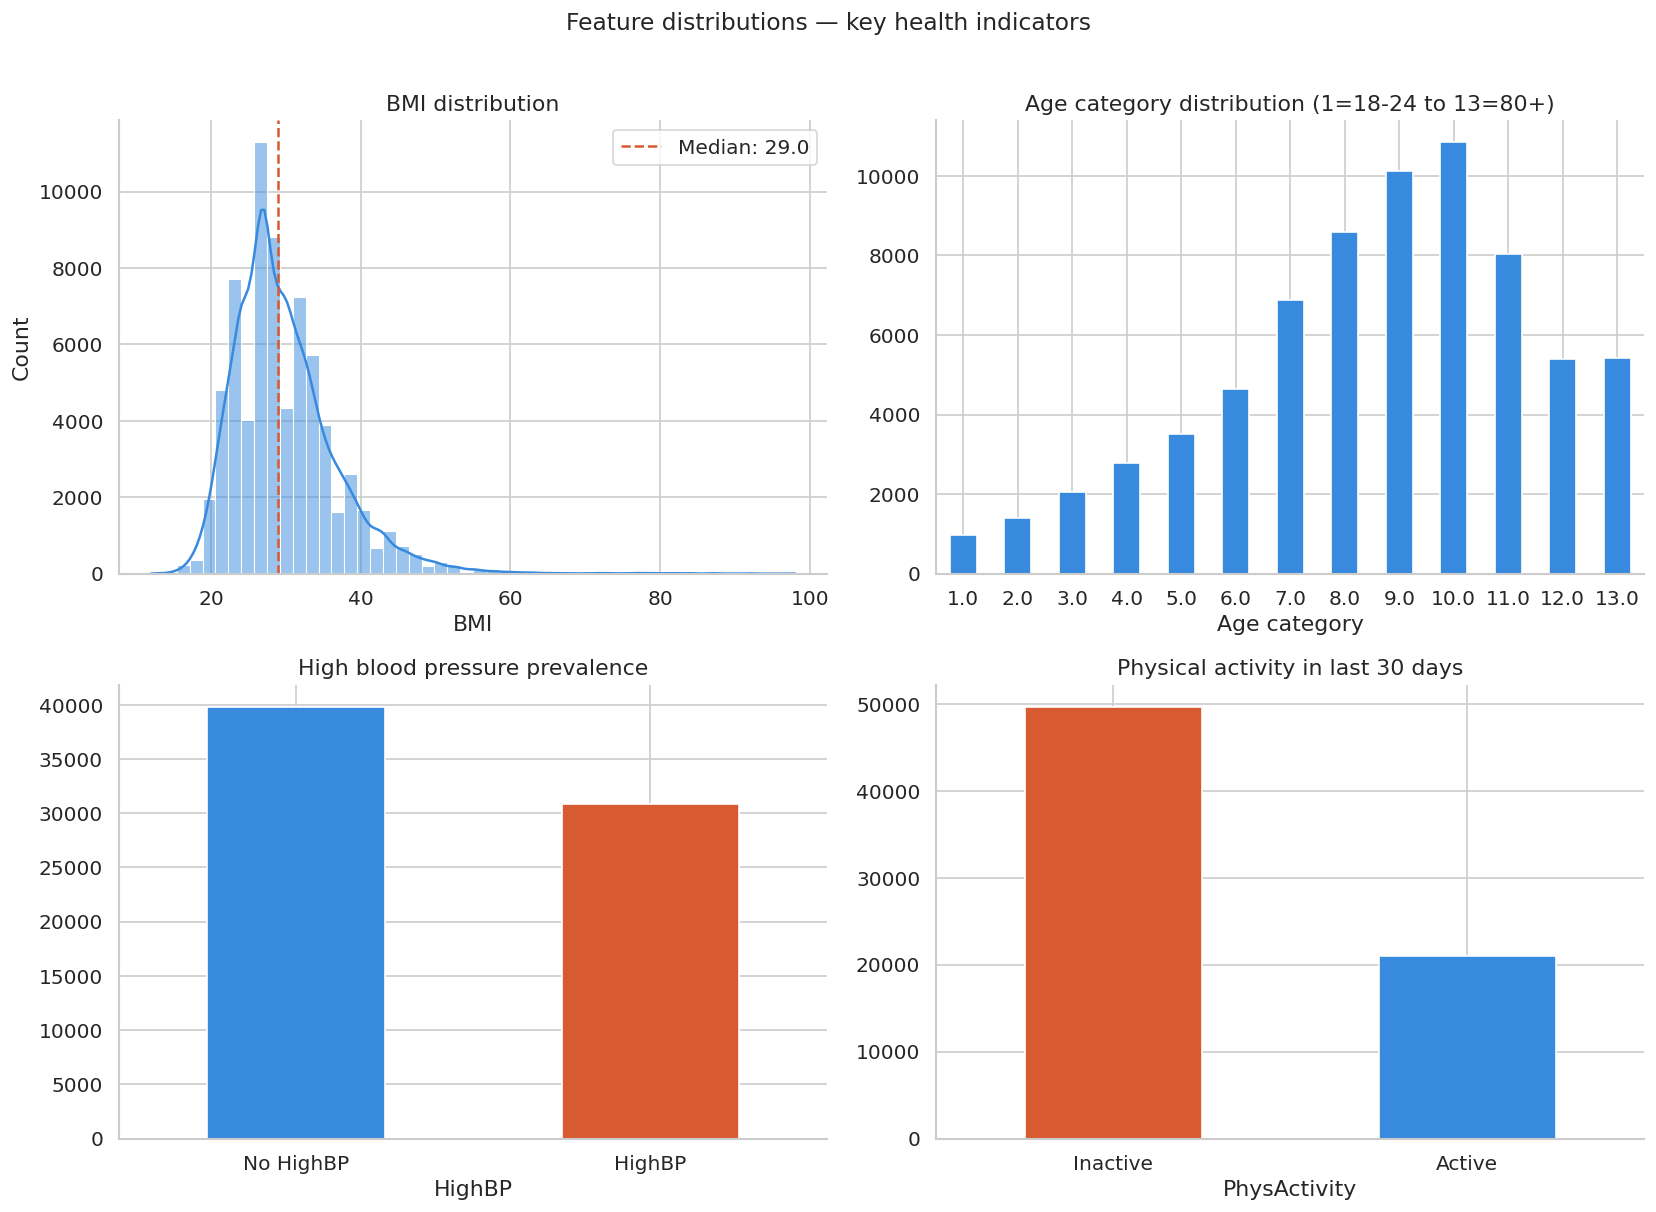

Interpretation: BMI is right-skewed with a long tail above 40 (obesity range).


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature distributions — key health indicators', fontsize=14, y=1.01)

# BMI: continuous -> histogram + KDE
sns.histplot(df['BMI'], kde=True, bins=50, ax=axes[0, 0], color='#378ADD')
axes[0, 0].set_title('BMI distribution')
axes[0, 0].axvline(df['BMI'].median(), color='#D85A30', linestyle='--',
                   label=f'Median: {df["BMI"].median():.1f}')
axes[0, 0].legend()

# Age: ordinal -> bar chart
df['Age'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 1], color='#378ADD', edgecolor='white')
axes[0, 1].set_title('Age category distribution (1=18-24 to 13=80+)')
axes[0, 1].set_xlabel('Age category')
axes[0, 1].tick_params(axis='x', rotation=0)

# HighBP: binary -> bar chart
df['HighBP'].value_counts().plot(
    kind='bar', ax=axes[1, 0], color=['#378ADD', '#D85A30'], edgecolor='white')
axes[1, 0].set_title('High blood pressure prevalence')
axes[1, 0].set_xticklabels(['No HighBP', 'HighBP'], rotation=0)

# PhysActivity: binary -> bar chart
df['PhysActivity'].value_counts().plot(
    kind='bar', ax=axes[1, 1], color=['#D85A30', '#378ADD'], edgecolor='white')
axes[1, 1].set_title('Physical activity in last 30 days')
axes[1, 1].set_xticklabels(['Inactive', 'Active'], rotation=0)

plt.tight_layout()
plt.savefig('01_distributions.png', bbox_inches='tight')
plt.show()
print('Interpretation: BMI is right-skewed with a long tail above 40 (obesity range).')

## Section 5 — Step 2: Correlation matrix

Pearson correlation across all 22 features. Upper triangle masked to avoid duplication.  
Pairs with |r| > 0.3 are printed — these are worth investigating as predictors or multicollinearity risks.

Pairs with |r| > 0.3:
GenHlth          PhysHlth    0.552757
PhysHlth         DiffWalk    0.487976
GenHlth          DiffWalk    0.476639
Education        Income      0.460565
Diabetes_binary  GenHlth     0.407612
                 HighBP      0.381516
MentHlth         PhysHlth    0.380272
HighBP           Age         0.338132
                 GenHlth     0.320540
                 HighChol    0.316515
GenHlth          MentHlth    0.315077
DiffWalk         Income     -0.343245
GenHlth          Income     -0.382969


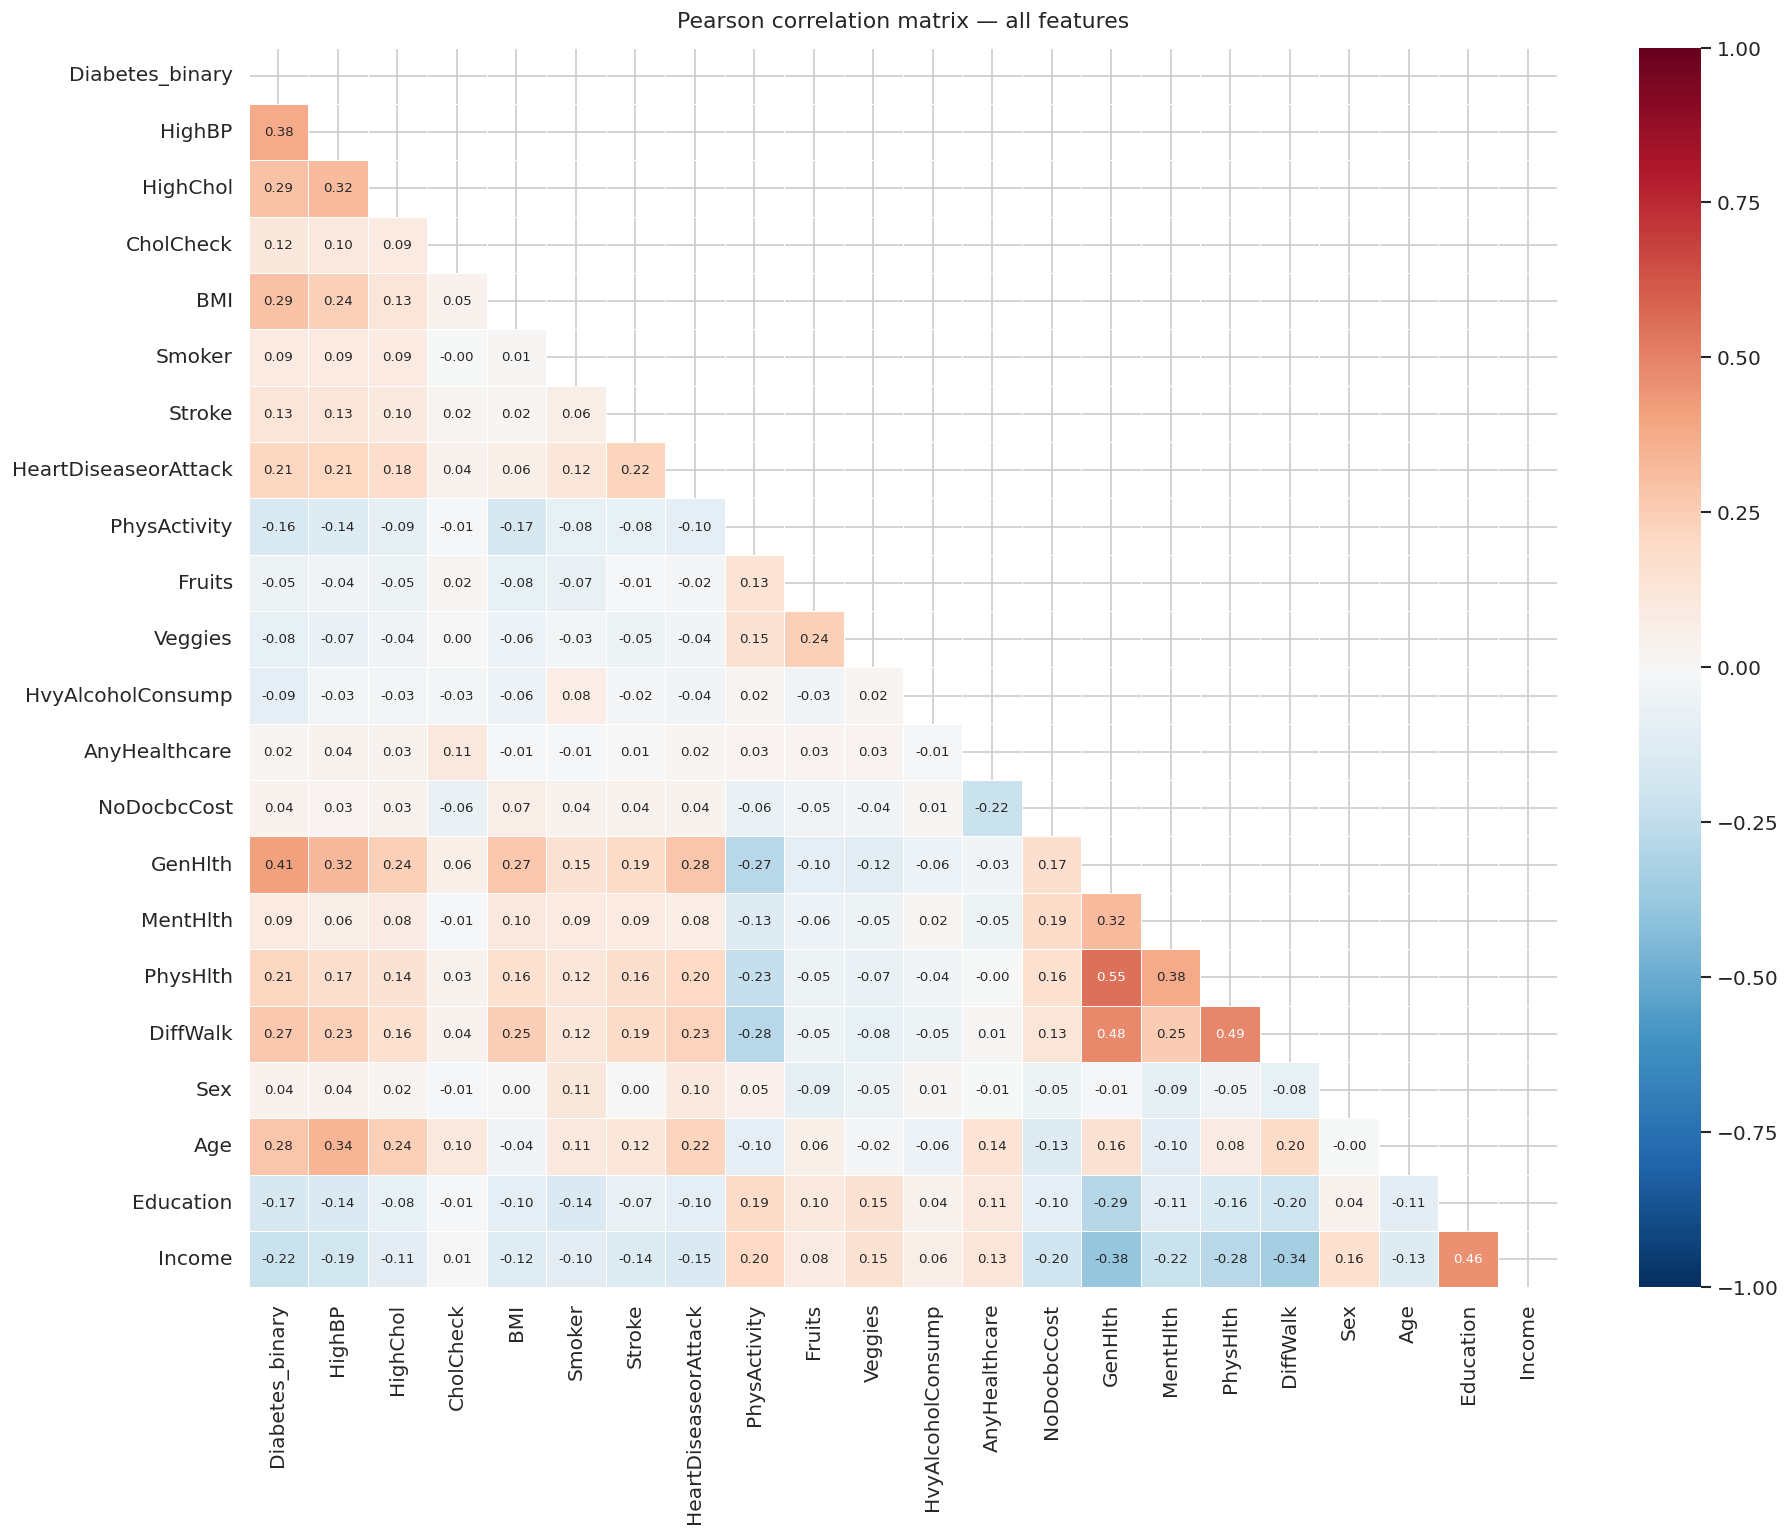

In [ ]:
corr = df.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson correlation matrix — all features', pad=12)

# Print strong pairs
strong = (corr.abs() > 0.3) & (corr != 1.0)
pairs = corr[strong].stack().drop_duplicates().sort_values(ascending=False)
print('Pairs with |r| > 0.3:')
print(pairs.to_string())

plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Section 6 — Step 3: BMI by diabetes group (violin plot)

Violin plots combine distribution shape with a boxplot.  
Comparing BMI across target groups reveals if diabetic patients cluster at higher BMI values.

Median BMI — No diabetes: 27.0
Median BMI — Diabetes: 31.0


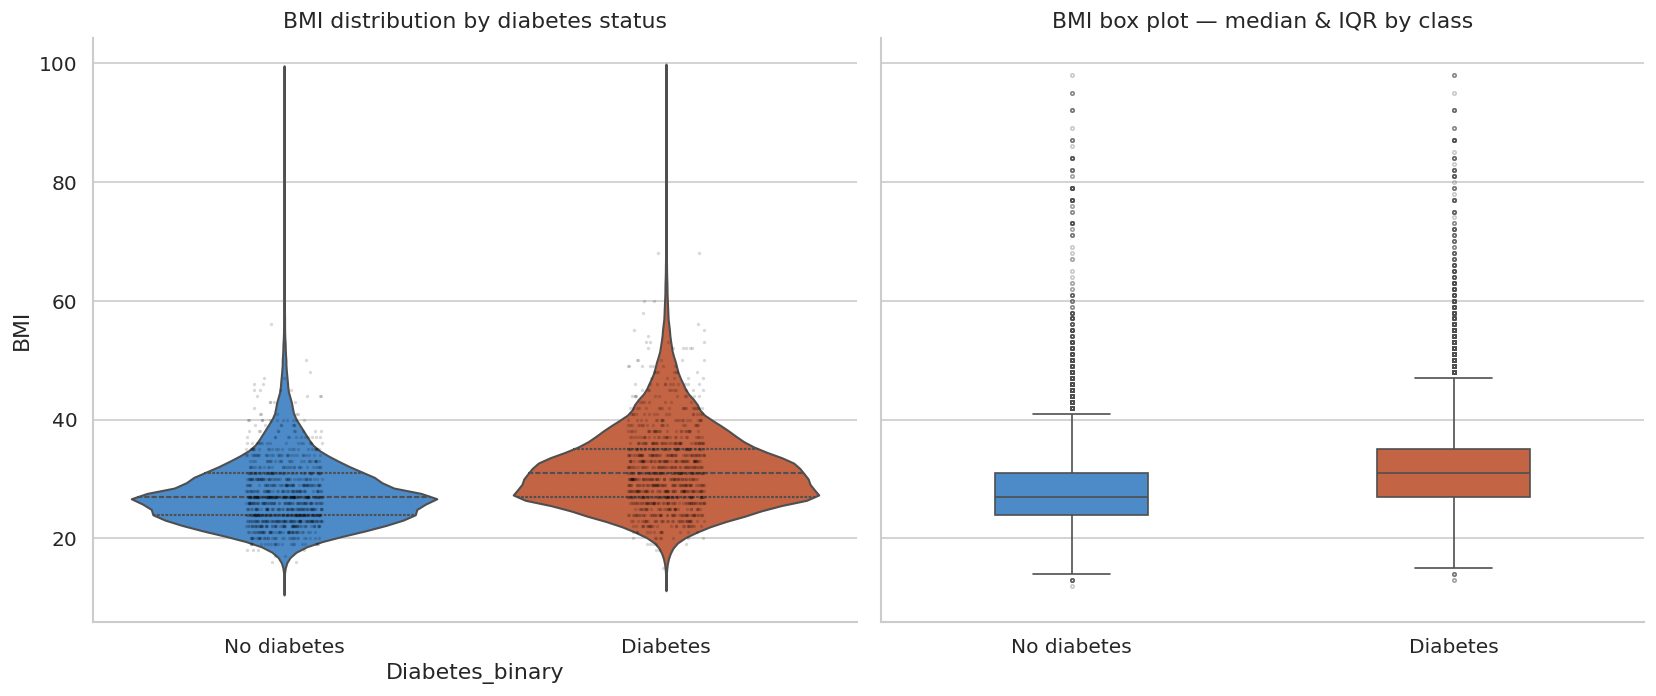

In [ ]:
# --- Fix for seaborn 0.12+: cast target to string so palette dict works correctly ---
df_plot = df.copy()
df_plot[TARGET] = df_plot[TARGET].map({0: 'No diabetes', 1: 'Diabetes'})
sample_plot = df_plot.sample(2000, random_state=42)
COLOR_MAP = ['#378ADD', '#D85A30']  # No diabetes=blue, Diabetes=coral
ORDER = ['No diabetes', 'Diabetes']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Violin plot
sns.violinplot(
    data=df_plot, x=TARGET, y='BMI',
    order=ORDER, palette=COLOR_MAP,
    inner='quartile', ax=axes[0]
)
axes[0].set_title('BMI distribution by diabetes status')
axes[0].set_xlabel('')

# Strip overlay (sampled to avoid overplotting)
sns.stripplot(
    data=sample_plot, x=TARGET, y='BMI',
    order=ORDER, color='black',
    alpha=0.15, size=2, ax=axes[0]
)

# Box plot for median comparison
sns.boxplot(
    data=df_plot, x=TARGET, y='BMI',
    order=ORDER, palette=COLOR_MAP,
    width=0.4, ax=axes[1],
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1].set_title('BMI box plot — median & IQR by class')
axes[1].set_xlabel('')

# Print medians
for label in ORDER:
    med = df_plot[df_plot[TARGET] == label]['BMI'].median()
    print(f'Median BMI — {label}: {med:.1f}')

plt.tight_layout()
plt.savefig('03_bmi_violin.png', bbox_inches='tight')
plt.show()

## Section 7 — Step 4: Top 5 features by mutual information

Mutual information captures non-linear relationships that Pearson misses — important for binary/ordinal health survey features.  
Use this ranking to prioritise features before any modelling step.

Top 5 features by mutual information score:
GenHlth     0.096661
HighBP      0.082962
BMI         0.055356
HighChol    0.048722
Age         0.047137


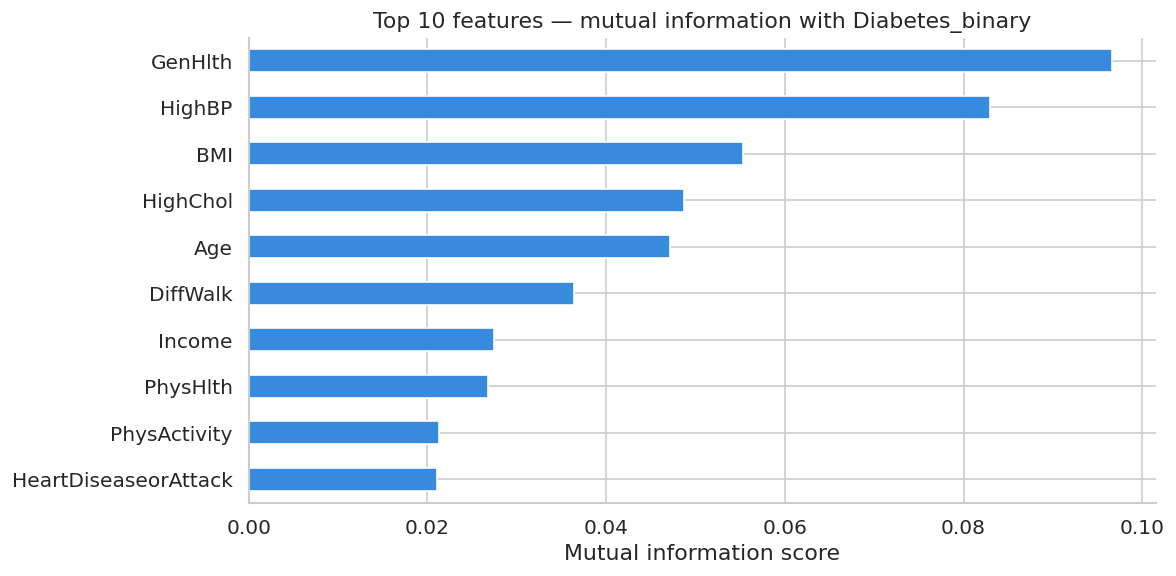

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print('Top 5 features by mutual information score:')
print(mi_df.head(5).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
mi_df.head(10).plot(kind='barh', ax=ax, color='#378ADD', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 10 features — mutual information with Diabetes_binary')
ax.set_xlabel('Mutual information score')

plt.tight_layout()
plt.savefig('04_mutual_info.png', bbox_inches='tight')
plt.show()

## Section 8 — Step 5: Class imbalance check

Class imbalance directly affects model evaluation.  
A classifier predicting all zeros achieves ~86% accuracy on this dataset — completely useless clinically.  
Always flag the ratio and recommend a mitigation strategy.

Class 0 (no diabetes): 35,346 (50.0%)
Class 1 (diabetes):    35,346 (50.0%)
Imbalance ratio:       1.0:1

Recommended mitigations:
  1. Use SMOTE or class_weight="balanced" before modelling
  2. Evaluate with AUC-ROC and F1, not accuracy
  3. Set classification threshold via precision-recall curve


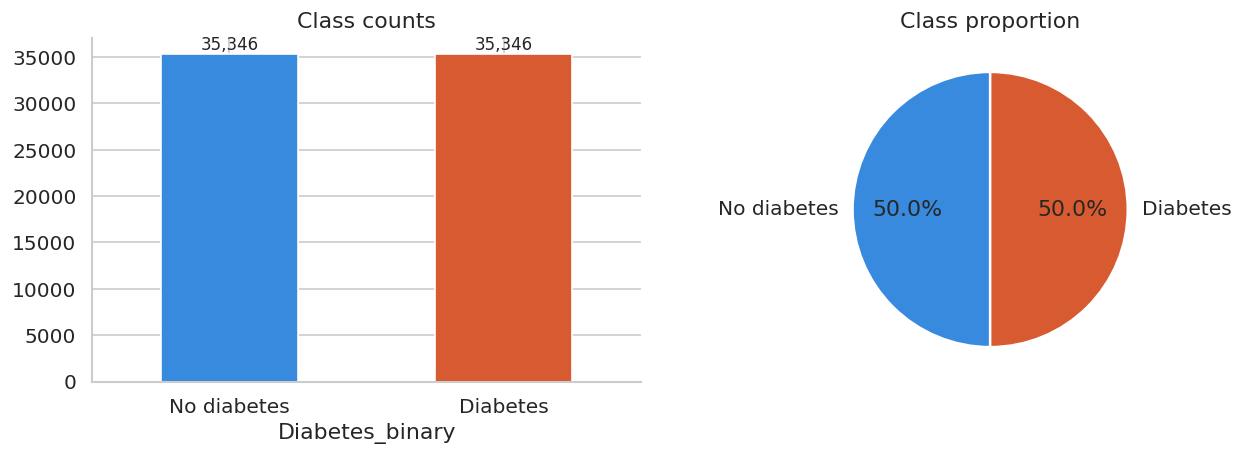

In [ ]:
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True) * 100
ratio = counts[0] / counts[1]

print(f'Class 0 (no diabetes): {counts[0]:,} ({pct[0]:.1f}%)')
print(f'Class 1 (diabetes):    {counts[1]:,} ({pct[1]:.1f}%)')
print(f'Imbalance ratio:       {ratio:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts.plot(kind='bar', ax=axes[0],
            color=['#378ADD', '#D85A30'], edgecolor='white', rot=0)
axes[0].set_title('Class counts')
axes[0].set_xticklabels(['No diabetes', 'Diabetes'])
for i, v in enumerate(counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(
    counts,
    labels=['No diabetes', 'Diabetes'],
    autopct='%1.1f%%',
    colors=['#378ADD', '#D85A30'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Class proportion')

print('\nRecommended mitigations:')
print('  1. Use SMOTE or class_weight="balanced" before modelling')
print('  2. Evaluate with AUC-ROC and F1, not accuracy')
print('  3. Set classification threshold via precision-recall curve')

plt.tight_layout()
plt.savefig('05_class_imbalance.png', bbox_inches='tight')
plt.show()

## Section 9 — EDA summary & next steps

Fill in after running all cells above:

| Finding | Detail |
|---------|--------|
| BMI | Right-skewed; diabetic median ~3 pts higher |
| Top predictors | GenHlth, HighBP, BMI, Age, HighChol |
| Class imbalance | ~86:14 — use SMOTE + AUC-ROC |
| Strong correlations | PhysHlth <-> MentHlth, HighBP <-> HeartDisease |

### Next steps
- [ ] Logistic regression baseline with `class_weight='balanced'`
- [ ] XGBoost with SMOTE oversampling
- [ ] SHAP feature importance visualisation
- [ ] Precision-recall curve and threshold tuning